# **Análisis de Datos (190304018-1 ) 2026-1** | **Entrega 2** |

**Integrantes del equipo:**
*   Mariana Villegas Ochoa
*   Melisa Colorado Soto
*   Jaider Santiago Villa David
*   Hernán Darío Flórez Martínez
---

# **Fase 1: Exploración de Base de datos** | **Dataset 3: Credit Card Fraud Detection** |

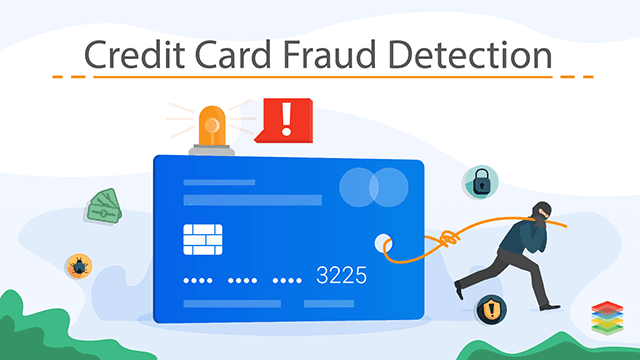

## **Generalidades del dataset**
La detección de transacciones fraudulentas es una necesidad crítica para las entidades emisoras de tarjetas de crédito, con el fin de proteger a los clientes de cargos no autorizados. Este dataset, disponible en Kaggle, reúne transacciones reales realizadas por titulares europeos durante septiembre de 2013, registradas a lo largo de dos días. De un total de 284 807 operaciones, 492 corresponden a fraudes, lo que representa el 0,172 % del total y evidencia un marcado desbalance entre clases. Al haber sido recopilada previamente por una entidad financiera y publicada para análisis, se clasifica como fuente secundaria, presentada en formato tabular (.csv).

Todas las variables son numéricas producto de una transformación PCA aplicada por razones de confidencialidad. Los componentes V1 a V28 corresponden a las variables transformadas, mientras que "Time" y "Amount" conservan su forma original: la primera indica los segundos transcurridos desde la primera transacción del conjunto, y la segunda refleja el monto de cada operación, siendo útil para enfoques de aprendizaje sensible al costo. La variable "Class" es la variable objetivo, con valor 1 para fraude y 0 para transacciones legítimas.

Su documentación es alta, aunque las variables se encuentran anonimizadas. Entre sus aplicaciones destacan la detección de fraude, el desarrollo de modelos de Machine Learning y el análisis de datos desbalanceados. Dado este desbalance, se recomienda evaluar el rendimiento mediante el área bajo la curva de precisión-exhaustividad (AUPRC), ya que métricas convencionales como la exactitud no resultan representativas en este tipo de escenarios. En términos generales, presenta alta completitud, relevancia y documentación, con una manejabilidad media, lo que lo convierte en un recurso muy adecuado para proyectos de clasificación y detección de fraude en contextos reales.

El dataset puede consutlarse en: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

## **Características de dataset**
  * Registros: 284,807
  * Atributos: 31 (28 anonimizados + Time + Amount + Class)
  * Tamaño: ~150 MB
  * Problema: Clasificación binaria (fraude / no fraude)
  * Nota: Datos altamente desbalanceados

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [ ]:
# Bloque 1: Importación de librerías y carga de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_palette("husl")

# Ubicación del dataset (archivo descargado de Kaggle)
path_dataset = path + "/creditcard.csv"

# Cargar el dataset
df = pd.read_csv(path_dataset)

# Visualización rápida
print("Dimensiones del dataset:", df.shape)
print("\nPrimeras filas:")
print(df.head())

print("\nInformación general:")
print(df.info())

Dimensiones del dataset: (284807, 31)

Primeras filas:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  

In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

Filas: 284807, Columnas: 31


# **Fase 2: Análisis Explroratorio de Datos (EDA)**

In [ ]:
# Importación de librerías
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

Valores nulos por columna:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Porcentaje de valores nulos (%):
Time      0.0
V1        0.0
V2        0.0
V3        0.0
V4        0.0
V5        0.0
V6        0.0
V7        0.0
V8        0.0
V9        0.0
V10       0.0
V11       0.0
V12       0.0
V13       0.0
V14       0.0
V15       0.0
V16       0.0
V17       0.0
V18       0.0
V19       0.0
V20       0.0
V21       0.0
V22       0.0
V23       0.0
V24       0.0
V25       0.0
V26       0.0
V27       0.0
V28       0.0
Amount    0.0
Class     0.0
dtype: float64

Resumen de columnas con valores faltantes:
Empty DataFrame
Columns: [Valores Nulos, Porcentaje (%)]
Inde

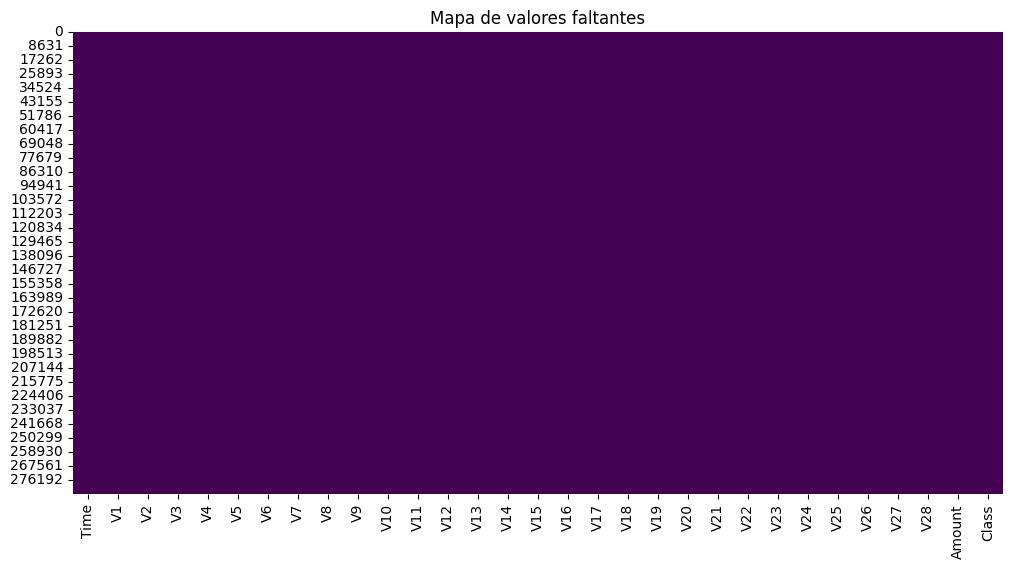

In [ ]:
# 1. Conteo de valores nulos por columna
valores_nulos = df.isnull().sum()

print("Valores nulos por columna:")
print(valores_nulos)

# 2. Porcentaje de valores nulos
porcentaje_nulos = (df.isnull().sum() / len(df)) * 100

print("\nPorcentaje de valores nulos (%):")
print(porcentaje_nulos)

# 3. Crear un DataFrame resumen
resumen_nulos = pd.DataFrame({
    'Valores Nulos': valores_nulos,
    'Porcentaje (%)': porcentaje_nulos
})

# Filtrar solo columnas con nulos
resumen_nulos = resumen_nulos[resumen_nulos['Valores Nulos'] > 0]

print("\nResumen de columnas con valores faltantes:")
print(resumen_nulos)

# 4. Visualización (heatmap)
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Mapa de valores faltantes")
plt.show()

In [ ]:
#Medidas y tomas de estrategia
resumen = []

for col in df.columns:

    total = len(df)
    nulos = df[col].isnull().sum()
    porcentaje_nulos = (nulos / total) * 100

    tipo = df[col].dtype

    # Medidas solo para numéricas
    if np.issubdtype(tipo, np.number):
        media = df[col].mean()
        mediana = df[col].median()
        moda = df[col].mode()[0] if not df[col].mode().empty else np.nan
        std = df[col].std()
        minimo = df[col].min()
        maximo = df[col].max()
    else:
        media = mediana = std = minimo = maximo = np.nan
        moda = df[col].mode()[0] if not df[col].mode().empty else np.nan

    # Estrategia automática
    if porcentaje_nulos == 0:
        estrategia = "Sin acción"
    elif porcentaje_nulos < 5:
        estrategia = "Imputación (media/mediana/moda)"
    elif porcentaje_nulos < 30:
        estrategia = "Imputación + indicador"
    else:
        estrategia = "Eliminar columna"

    resumen.append({
        "Columna": col,
        "Tipo": tipo,
        "Nulos": nulos,
        "% Nulos": porcentaje_nulos,
        "Media": media,
        "Mediana": mediana,
        "Moda": moda,
        "Std": std,
        "Minimo": minimo,
        "Maximo": maximo,
        "Estrategia Sugerida": estrategia
    })

# Convertir a DataFrame
resumen_df = pd.DataFrame(resumen)

# Mostrar resultados
pd.set_option('display.max_columns', None)
print(resumen_df)


   Columna     Tipo  Nulos  % Nulos         Media       Mediana  \
0     Time  float64      0      0.0  9.481386e+04  84692.000000   
1       V1  float64      0      0.0  1.168375e-15      0.018109   
2       V2  float64      0      0.0  3.416908e-16      0.065486   
3       V3  float64      0      0.0 -1.379537e-15      0.179846   
4       V4  float64      0      0.0  2.074095e-15     -0.019847   
5       V5  float64      0      0.0  9.604066e-16     -0.054336   
6       V6  float64      0      0.0  1.487313e-15     -0.274187   
7       V7  float64      0      0.0 -5.556467e-16      0.040103   
8       V8  float64      0      0.0  1.213481e-16      0.022358   
9       V9  float64      0      0.0 -2.406331e-15     -0.051429   
10     V10  float64      0      0.0  2.239053e-15     -0.092917   
11     V11  float64      0      0.0  1.673327e-15     -0.032757   
12     V12  float64      0      0.0 -1.247012e-15      0.140033   
13     V13  float64      0      0.0  8.190001e-16     -0.01356

# **Fase 3: Preprocesamiento y reducción**